<a href="https://colab.research.google.com/github/softwareJengineer/DSC-445-hw/blob/main/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Jennifer Schwabe
### 2241210
### DSC 445
### HW 2
### *I have completed this work independently. The solutions given are entirely my own work.*

# Problem 1

## a.
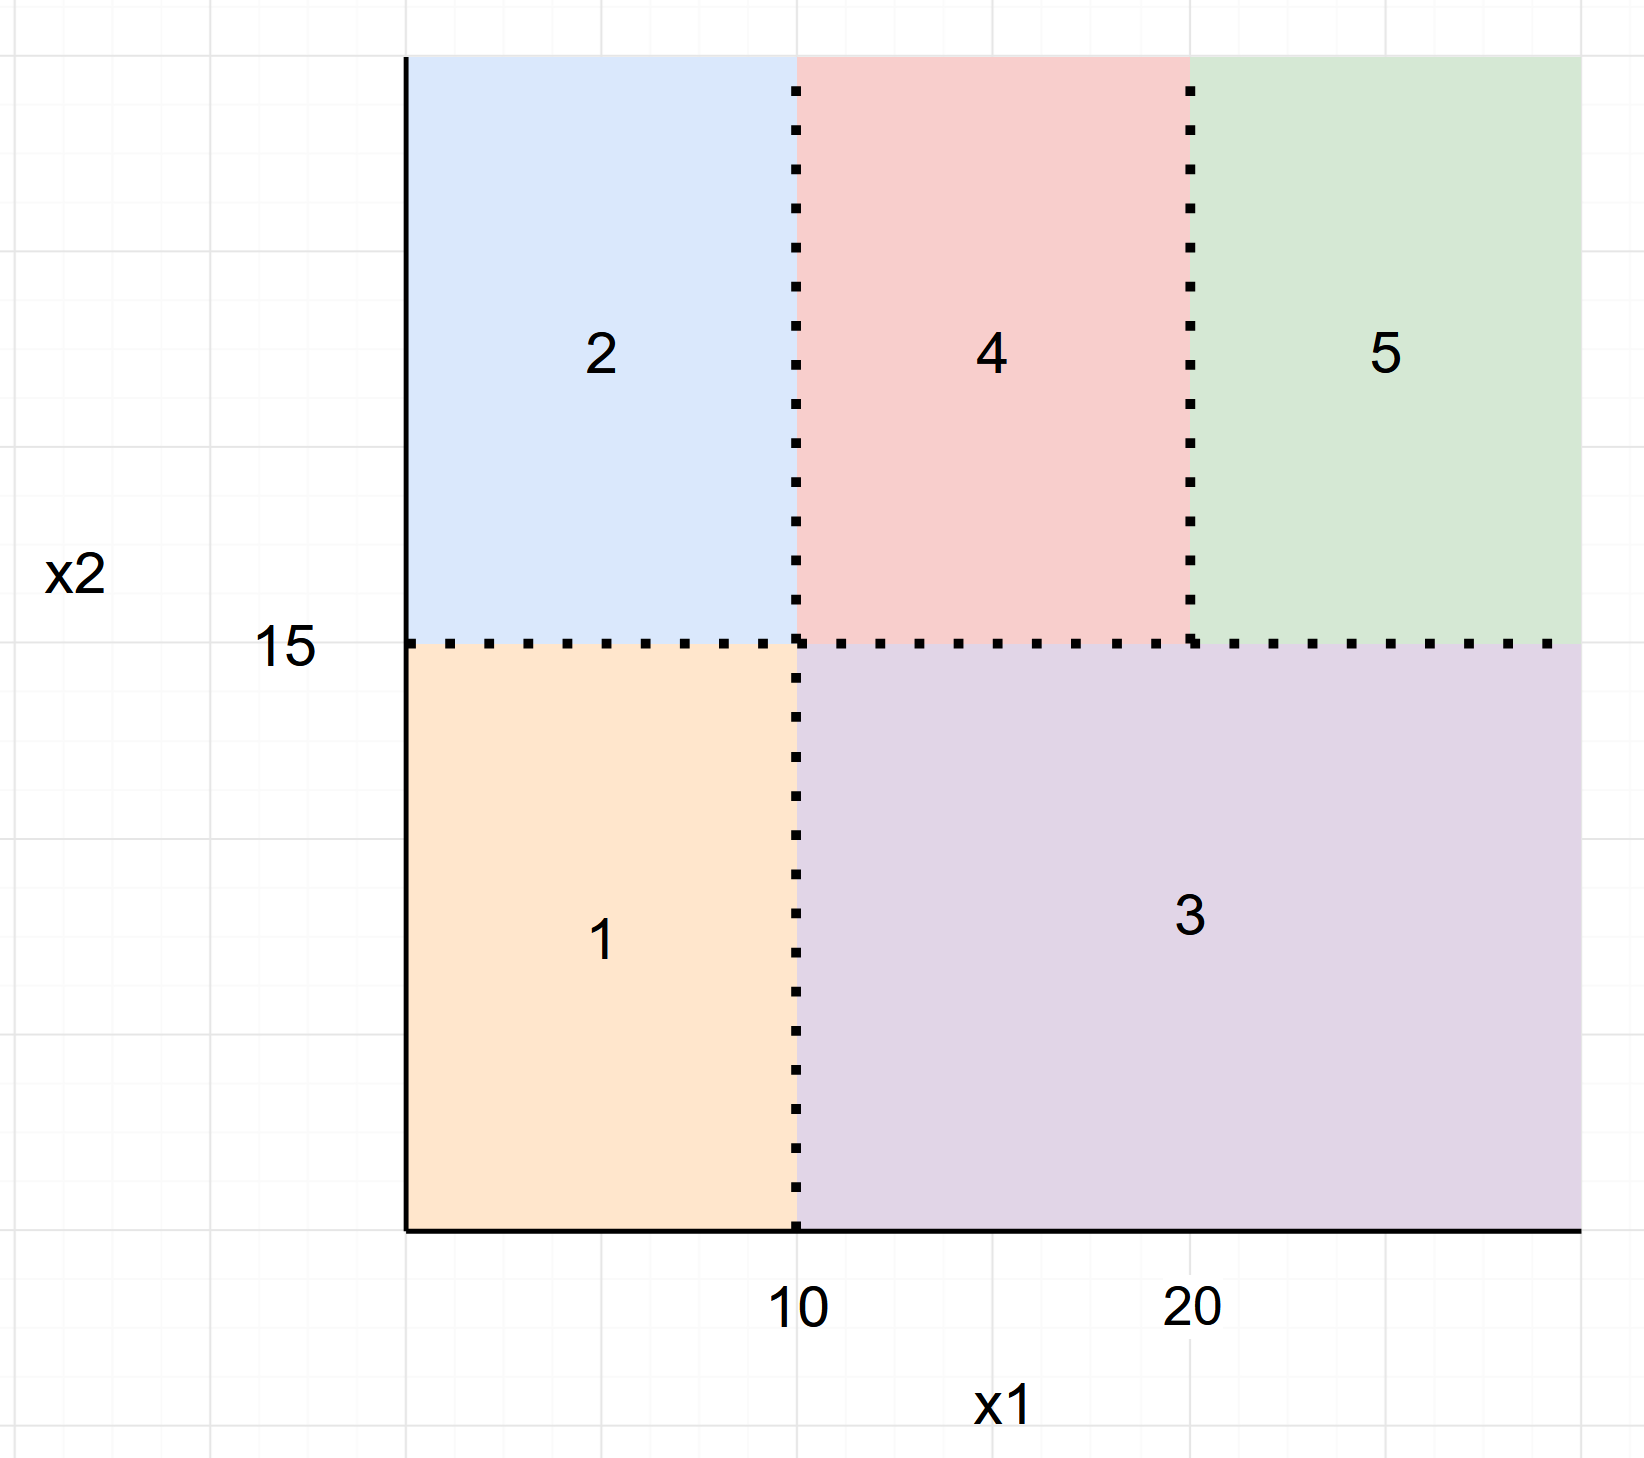

## b.
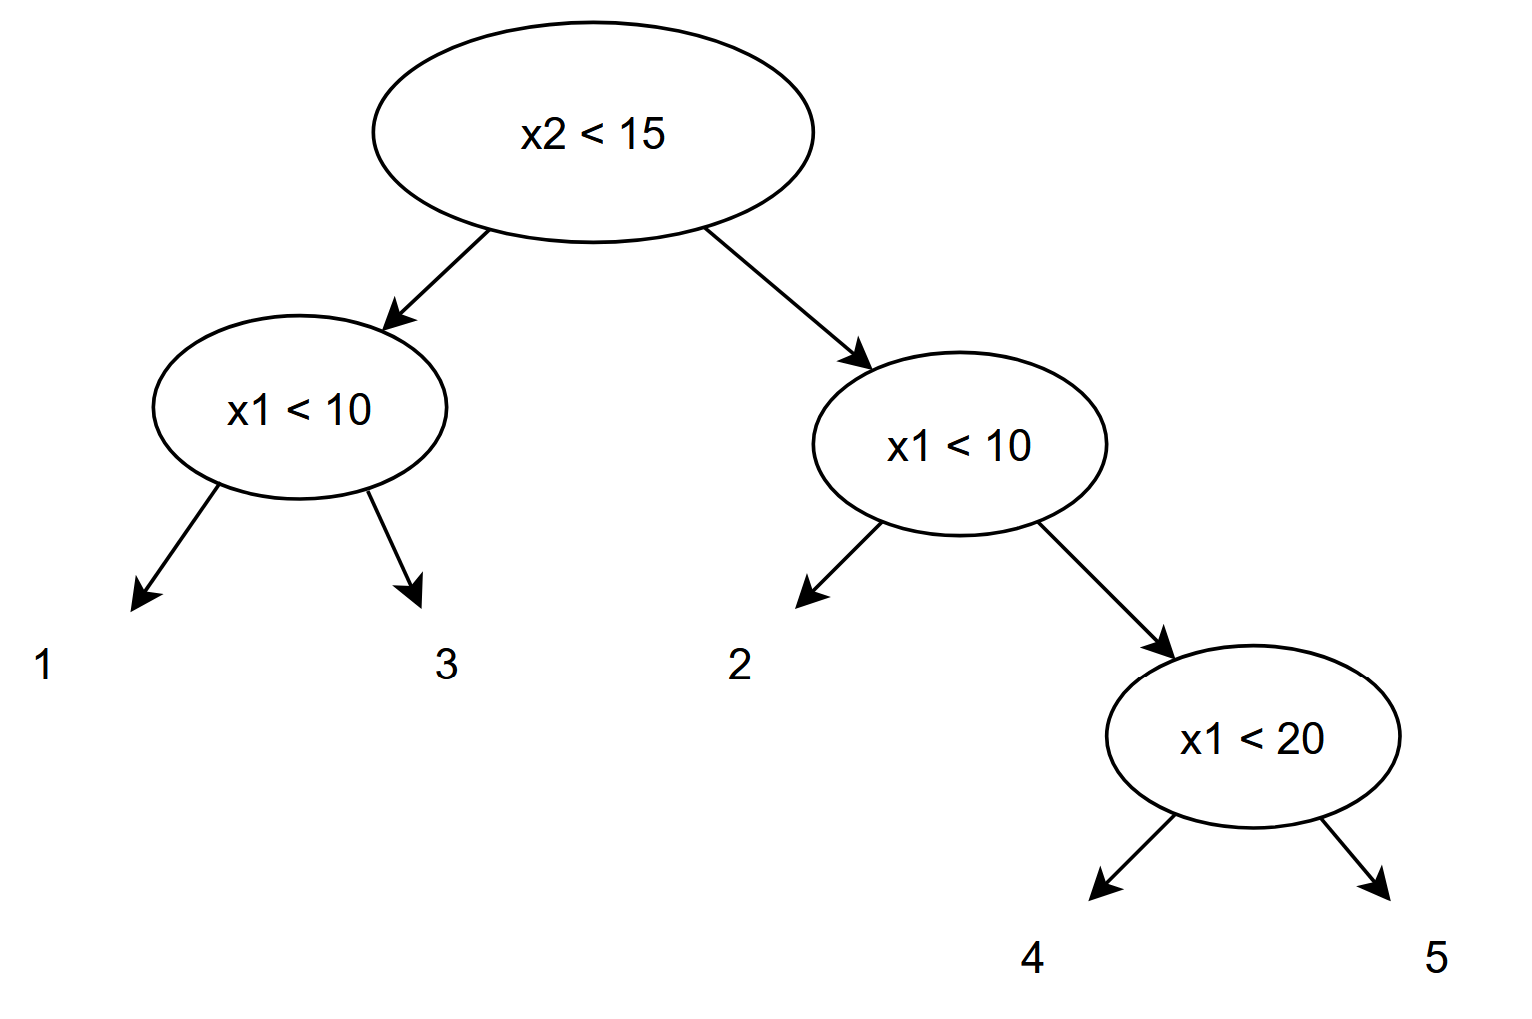

## c.

According to the diagram before partitioning, there are 3 points in class 1, 1 point in class 2, 3 points in class 3, 3 points in class 4, and 1 point in class 5, for 11 points overall.

Gini index before classification:

$G_{all}=\frac{3}{11}(1-\frac{3}{11})+\frac{1}{11}(1-\frac{1}{11})+\frac{3}{11}(1-\frac{3}{11})+\frac{3}{11}(1-\frac{3}{11})+\frac{1}{11}(1-\frac{1}{11})=0.893$

After partitioning, we have 5 sections, as shown below:

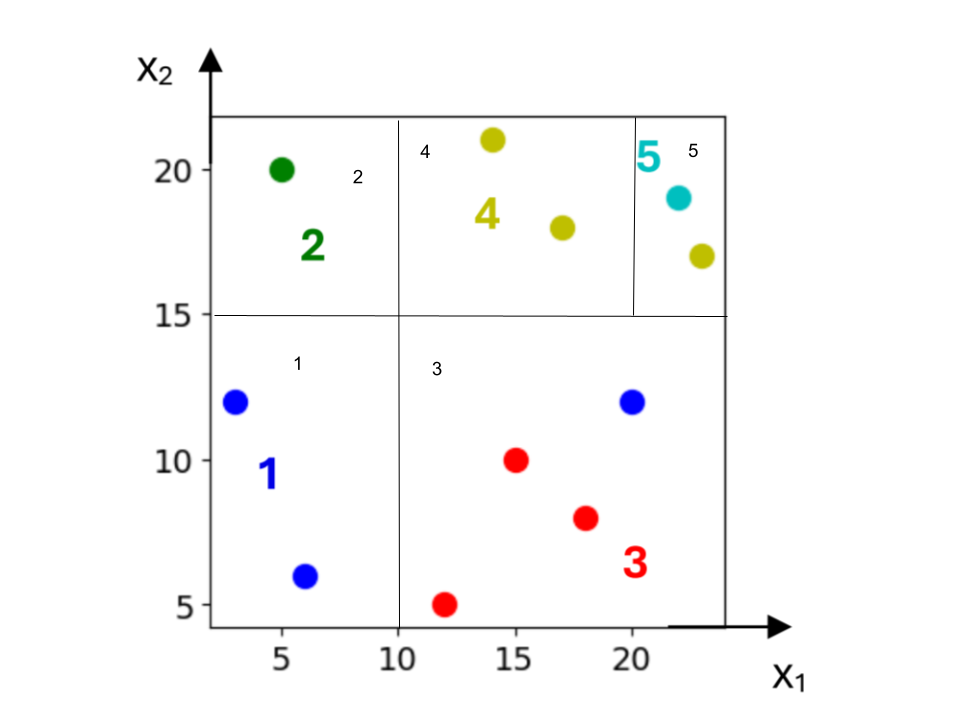

Section 1 has 2 points in class 1. Section 2 has 1 point in class 2. Section 3 has 3 points in class 3 and 1 point in class 2. Section 4 has 2 points in class 4. Section 5 has 1 point in class 4 and 1 point in class 5. The Gini index for each section is shown below:

$Gini_{1}=\frac{2}{2}(1-\frac{2}{2})=0$

$Gini_{2}=\frac{1}{1}(1-\frac{1}{1})=0$

$Gini_{3}=\frac{3}{4}(1-\frac{3}{4})+\frac{1}{4}(1-\frac{1}{4})=0.375$

$Gini_{4}=\frac{2}{2}(1-\frac{2}{2})=0$

$Gini_{5}=\frac{1}{2}(1-\frac{1}{2})+\frac{1}{2}(1-\frac{1}{2})=0.5$

So the overall Gini for classifier 1 would be:

$Gini_{classifier}=\frac{0+0+0.375+0+0.5}{5}=0.175$

# Problem 2


In [7]:
from tensorflow import keras
import pandas as pd
import numpy as np

dat=pd.read_csv("obesity_prediction.csv")
X = dat.iloc[:,:-1].to_numpy()
y = dat.iloc[:,-1].to_numpy()

## a.

In [8]:
from sklearn.preprocessing import OneHotEncoder
X_cat = X[:,8:]
X_num = X[:,:8]
X_cat = OneHotEncoder(sparse_output=False).fit_transform(X_cat)
X = np.concatenate((X_num, X_cat), axis=1)
X = np.float32(X)
C = np.unique(y)
print(X.shape)
print(C)
print(X[0:3])

(2111, 31)
['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']
[[21.    1.62 64.    2.    3.    2.    0.    1.    1.    0.    0.    1.
   1.    0.    0.    0.    1.    0.    1.    0.    1.    0.    0.    0.
   0.    1.    0.    0.    0.    1.    0.  ]
 [21.    1.52 56.    3.    3.    3.    3.    0.    1.    0.    0.    1.
   1.    0.    0.    0.    1.    0.    0.    1.    0.    1.    0.    0.
   1.    0.    0.    0.    0.    1.    0.  ]
 [23.    1.8  77.    2.    3.    2.    2.    1.    0.    1.    0.    1.
   1.    0.    0.    0.    1.    0.    1.    0.    1.    0.    0.    1.
   0.    0.    0.    0.    0.    1.    0.  ]]


The new X has 2111 rows and 54 columns. There are 7 unique class labels.

## b.

In [9]:
from sklearn.preprocessing import LabelEncoder
y = LabelEncoder().fit_transform(y)
print(np.unique(y))

[0 1 2 3 4 5 6]


np.unique on the new y gives an array of values from 0 to 6. This is expected, as there were 7 unique class labels originally.

## c.


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import set_random_seed
from tensorflow.random import set_seed
randstate = 12
set_random_seed(randstate)
set_seed(randstate)
model = Sequential()
model.add(Dense(len(C),activation='softmax'))

We needed "softmax" activation for this layer because there were multiple output classes possible for the model. This means that there will be multiple neurons in the output layer, and softmax activation will transform the model's output into a list of probabilities for each target class. Then, we can use this list of probabilities to select the most likely class that a test point belongs to.

## d.


In [22]:
from sklearn.model_selection import train_test_split

model.compile(loss='sparse_categorical_crossentropy',optimizer='SGD',metrics=['accuracy'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=randstate)
print(X_train.shape, X_test.shape)

(1477, 31) (634, 31)


The training data has 1,477 points and the test data has 634 points. Both sets have 31 features.

## e.


In [23]:
model.fit(X_train, y_train, batch_size=5, epochs=100)
print(model.summary())
eval = model.evaluate(X_test, y_test)
print(eval)

Epoch 1/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1733 - loss: 32.7926
Epoch 2/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2302 - loss: 26.5927
Epoch 3/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2329 - loss: 25.2703
Epoch 4/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2363 - loss: 25.0790
Epoch 5/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2471 - loss: 23.7040
Epoch 6/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2437 - loss: 23.8395
Epoch 7/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2708 - loss: 22.8351
Epoch 8/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2850 - loss: 22.5452
Epoch 9/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2803 - loss: 21.2459
Epoch 10/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2837 - loss: 20.8514
Epoch 11/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2762 - loss: 22.0133
Epoch 12/100
296/296 ━━━━━━━━━

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 7)              │           224 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226 (908.00 B)

 Trainable params: 224 (896.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

None
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4748 - loss: 13.7497  
[13.74974250793457, 0.4747633934020996]


Based on the output values for each epoch, the first epoch had an accuracy of 0.1733 and a loss of 32.79. The final epoch had an acuracy of 0.4929 and a loss of 10.28. model.summary() gave 224 trainable params. On the testing data, the model had an accuracy of 0.475 and a loss of 13.75.

## f.


In [27]:
set_random_seed(randstate)
set_seed(randstate)

model = Sequential()
model.add(Dense(len(C),activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
model.fit(X_train, y_train, batch_size=5, epochs=100)
model.evaluate(X_test, y_test)

Epoch 1/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0609 - loss: 12.3274
Epoch 2/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1909 - loss: 3.3927
Epoch 3/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2404 - loss: 2.7131
Epoch 4/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3230 - loss: 2.2164
Epoch 5/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3778 - loss: 1.8465
Epoch 6/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4116 - loss: 1.5807
Epoch 7/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4584 - loss: 1.3921
Epoch 8/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5010 - loss: 1.2593
Epoch 9/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5491 - loss: 1.1654
Epoch 10/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5762 - loss: 1.0973
Epoch 11/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5992 - loss: 1.0457
Epoch 12/100
296/296 ━━━━━━━━━━━━━━━━━━━

[0.6326117515563965, 0.7586750984191895]

Using Adam as the optimizer, the first epoch had an accuracy of 0.061 and a loss of 12.33, while the last epoch had an accuracy of 0.792 and a loss of 0.563. On the testing data, the model had an accuracy of 0.759 and a loss of 0.633. This model's performance was much better than the one that used SGD as the optimizer.

## g.

In [28]:
set_random_seed(randstate)
set_seed(randstate)

model = Sequential()
model.add(Dense(15, activation='relu'))
model.add(Dense(7, activation='softmax'))
set_random_seed(randstate)

model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
model.fit(X_train, y_train, batch_size=5, epochs=100)
print(model.summary())
model.evaluate(X_test, y_test)

Epoch 1/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1361 - loss: 7.6741 
Epoch 2/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2329 - loss: 1.9630
Epoch 3/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3162 - loss: 1.7188
Epoch 4/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3907 - loss: 1.5605
Epoch 5/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4536 - loss: 1.4283
Epoch 6/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5146 - loss: 1.3082
Epoch 7/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5443 - loss: 1.2095
Epoch 8/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5708 - loss: 1.1296
Epoch 9/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5944 - loss: 1.0631
Epoch 10/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6114 - loss: 1.0070
Epoch 11/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6188 - loss: 0.9588
Epoch 12/100
296/296 ━━━━━━━━━━━━━━━━━━━

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 15)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7)              │           112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,778 (6.95 KB)

 Trainable params: 592 (2.31 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,186 (4.64 KB)

None
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8549 - loss: 0.4551  


[0.45505136251449585, 0.8548895716667175]

Using the model with a hidden layer of size 15, the first epoch had an accuracy of 0.136 and a loss of 7.57 and the last epoch had an accuracy of 0.869 and a loss of 0.347. Running model.evaluate gave an accuracy of 0.855 and a loss of 0.455. The model had 592 trainable params. The end results of this new model were better than the models without hidden layers in terms of accuracy on both the training and test data.

# Problem 3

In [29]:
set_random_seed(randstate)
set_seed(randstate)

model = Sequential()
model.add(Dense(200, activation='relu'))
model.add(Dense(200, activation='relu'))
model.add(Dense(7, activation='softmax'))


## a.

In [30]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
model.fit(X_train, y_train, batch_size=5, epochs=100)
model.evaluate(X_test, y_test)

Epoch 1/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3135 - loss: 1.9128
Epoch 2/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5030 - loss: 1.1816
Epoch 3/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6046 - loss: 0.9185
Epoch 4/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6703 - loss: 0.7896
Epoch 5/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7062 - loss: 0.7113
Epoch 6/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7360 - loss: 0.6485
Epoch 7/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7590 - loss: 0.5967
Epoch 8/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7752 - loss: 0.5565
Epoch 9/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7840 - loss: 0.5215
Epoch 10/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7969 - loss: 0.4903
Epoch 11/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8064 - loss: 0.4668
Epoch 12/100
296/296 ━━━━━━━━━━━━━━━━━━━━

[0.6937558650970459, 0.8627760410308838]

Assuming using Adam as the optimizer, a batch size of 5, and 100 epochs, the training accuracy from the last epoch was 0.969 and the test accuracy was 0.863. This indicates that the model overfitted to the training data, as the model performed much better on the training data than on the test data. This difference shows that model learned the training data too well and struggled to generalize to unseen data.

## b.

In [34]:
from tensorflow.keras.regularizers import L2

set_random_seed(randstate)
set_seed(randstate)

model = Sequential()
c=0.002
model.add(Dense(200,activation='relu', kernel_regularizer=L2(c), bias_regularizer=L2(c)))
model.add(Dense(200,activation='relu', kernel_regularizer=L2(c), bias_regularizer=L2(c)))
model.add(Dense(7,activation='softmax',kernel_regularizer=L2(c), bias_regularizer=L2(c)))

model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
model.fit(X_train, y_train, batch_size=5, epochs=100)
model.evaluate(X_test, y_test)

Epoch 1/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3169 - loss: 2.1235
Epoch 2/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5037 - loss: 1.3560
Epoch 3/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6100 - loss: 1.1156
Epoch 4/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6777 - loss: 0.9896
Epoch 5/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7014 - loss: 0.9199
Epoch 6/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7312 - loss: 0.8638
Epoch 7/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7508 - loss: 0.8242
Epoch 8/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7637 - loss: 0.7905
Epoch 9/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7773 - loss: 0.7627
Epoch 10/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7827 - loss: 0.7395
Epoch 11/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7915 - loss: 0.7189
Epoch 12/100
296/296 ━━━━━━━━━━━━━━━━━━━━

[0.5680909752845764, 0.8785489201545715]

After adding L2 norm regularizers to each layer and setting the regularization coefficient to 0.002, the training accuracy of the last epoch was 0.915 and the test accuracy was 0.879. The training and test accuracies were closer for this model than for the model without L2 regularization, showing less overfitting.

## c.

In [36]:
from tensorflow.keras.layers import Dropout
set_random_seed(randstate)
set_seed(randstate)

dr = 0.1
model = Sequential()
model.add(Dense(200, activation='relu'))
model.add(Dropout(dr))
model.add(Dense(200, activation='relu'))
model.add(Dropout(dr))
model.add(Dense(7, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
model.fit(X_train, y_train, batch_size=5, epochs=100)
model.evaluate(X_test, y_test)

Epoch 1/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2742 - loss: 2.3844
Epoch 2/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4130 - loss: 1.4143
Epoch 3/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5085 - loss: 1.1296
Epoch 4/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5917 - loss: 0.9803
Epoch 5/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6439 - loss: 0.8341
Epoch 6/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6716 - loss: 0.7696
Epoch 7/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7021 - loss: 0.7100
Epoch 8/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7156 - loss: 0.6604
Epoch 9/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7373 - loss: 0.6277
Epoch 10/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7583 - loss: 0.5856
Epoch 11/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7664 - loss: 0.5558
Epoch 12/100
296/296 ━━━━━━━━━━━━━━━━━━━━

[0.5149827003479004, 0.8832807540893555]

After adding dropout layers after both hidden layers, the training accuracy of the last epoch was 0.953 and the test accuracy was 0.883. There was less overfitting compared to the very first model without dropout or normalization but more overfitting compared to the model with L2 regularization. The model still struggles to generalize to unseen data as compared to the training data.

## d.


In [37]:
# no regularization or dropout
set_random_seed(randstate)
set_seed(randstate)
model = Sequential()
model.add(Dense(200, activation='relu'))
model.add(Dense(200, activation='relu'))
model.add(Dense(7, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
res = model.fit(X_train, y_train, batch_size=5, epochs=100)
tr_acc_1 = res.history['accuracy']

# L2 regularization
set_random_seed(randstate)
set_seed(randstate)
model = Sequential()
c=0.002
model.add(Dense(200,activation='relu', kernel_regularizer=L2(c), bias_regularizer=L2(c)))
model.add(Dense(200,activation='relu', kernel_regularizer=L2(c), bias_regularizer=L2(c)))
model.add(Dense(7,activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
res = model.fit(X_train, y_train, batch_size=5, epochs=100)
tr_acc_2 = res.history['accuracy']

# dropout with dr=0.1
set_random_seed(randstate)
set_seed(randstate)
dr = 0.1
model = Sequential()
model.add(Dense(200, activation='relu'))
model.add(Dropout(dr))
model.add(Dense(200, activation='relu'))
model.add(Dropout(dr))
model.add(Dense(7, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
res = model.fit(X_train, y_train, batch_size=5, epochs=100)
tr_acc_3 = res.history['accuracy']

# dropout with dr=0.2
set_random_seed(randstate)
set_seed(randstate)
dr = 0.2
model = Sequential()
model.add(Dense(200, activation='relu'))
model.add(Dropout(dr))
model.add(Dense(200, activation='relu'))
model.add(Dropout(dr))
model.add(Dense(7, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
res = model.fit(X_train, y_train, batch_size=5, epochs=100)
tr_acc_4 = res.history['accuracy']

# dropout with dr=0.4
set_random_seed(randstate)
set_seed(randstate)
dr = 0.4
model = Sequential()
model.add(Dense(200, activation='relu'))
model.add(Dropout(dr))
model.add(Dense(200, activation='relu'))
model.add(Dropout(dr))
model.add(Dense(7, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
res = model.fit(X_train, y_train, batch_size=5, epochs=100)
tr_acc_5 = res.history['accuracy']

Epoch 1/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3135 - loss: 1.9128
Epoch 2/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5030 - loss: 1.1816
Epoch 3/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6046 - loss: 0.9185
Epoch 4/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6703 - loss: 0.7896
Epoch 5/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7062 - loss: 0.7113
Epoch 6/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7360 - loss: 0.6485
Epoch 7/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7590 - loss: 0.5967
Epoch 8/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7752 - loss: 0.5565
Epoch 9/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7840 - loss: 0.5215
Epoch 10/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7969 - loss: 0.4903
Epoch 11/100
296/296 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8064 - loss: 0.4668
Epoch 12/100
296/296 ━━━━━━━━━━━━━━━━━━━━

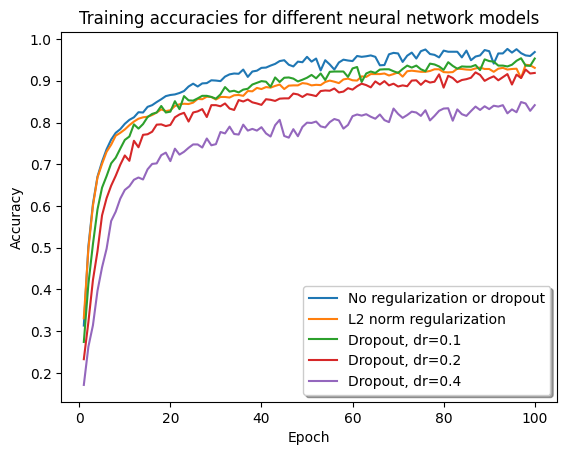

In [38]:
import matplotlib.pyplot as plt

x = np.arange(1,101)
plt.plot(x, tr_acc_1, label="No regularization or dropout")
plt.plot(x, tr_acc_2, label="L2 norm regularization")
plt.plot(x, tr_acc_3, label="Dropout, dr=0.1")
plt.plot(x, tr_acc_4, label="Dropout, dr=0.2")
plt.plot(x, tr_acc_5, label="Dropout, dr=0.4")
plt.title("Training accuracies for different neural network models")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(shadow=True, fancybox=True)
plt.show()

The graphs show an increase in accuracy over the epochs, starting wtih low accuracy and having higher accuracy by epoch 100. The model with the best training accuracy was the model without regularization or dropout, followed by the model using Dropout with rate=0.1, then the model using L2 norm regularization, then the model using Dropout with rate=0.2, and finally the model using Dropout with rate=0.4. The model without any regularization or dropout has the highest accuracy because there were no penalties or techniques used to reduce overfitting and increase generalizability. The model with Dropout rate 0.1 likely has the next highest training accuracy because the dropout rate is low enough that the dropout doesn't affect the model.